# Predicting House Prices in 2025: A Live ML Demo

**Goal:** Can we train a machine learning model to predict the price of a house in South Carolina based on the available data (input features)?

**Data:** Real 2025 listing data from Charleston, SC.
- **Features:** `type`, `sub_type`, `sqft`, `baths`, `beds`, `stories`, `year_built`
- **Target:** `listPrice`

In [1]:
# Import libraries (tools we need)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

### 📊 Step 1: Load and Explore the Data
This is real housing data from South Carolina's 2025 market - actual homes with real prices and features.

In [2]:
# Load the data
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

df = pd.read_csv('data/realestate_data_southcarolina_2025.csv')

print(f"📈 Dataset size: {len(df):,} properties")
print(f"\n📋 Features available: {', '.join(df.columns)}")
print(f"\n🏘️ First few properties:")
display(df.head())

📈 Dataset size: 5,001 properties

📋 Features available: type, sub_type, sqft, baths, beds, stories, year_built, listPrice

🏘️ First few properties:


,type,sub_type,sqft,baths,beds,stories,year_built,listPrice
0,condos,condo,1268.0,2.0,3.0,1.0,2002.0,199900.0
1,condos,condo,969.0,2.0,2.0,7.0,1985.0,119900.0
2,single_family,NaN,2181.0,3.0,3.0,2.0,NaN,100000.0
3,single_family,NaN,2083.0,2.0,3.0,NaN,1983.0,309900.0
4,land,NaN,NaN,0.0,NaN,NaN,NaN,1000.0


#### 🧹 Quick Data Cleaning
In real projects, up to 80% of your time goes to data cleaning and preprocessing. Here we'll do a quick cleanup for the demo:

In [3]:
# Focus on single-family homes only
df_clean = df[df['type'] == 'single_family'].copy()

# Keep only rows with complete data
df_clean = df_clean.dropna(subset=['sqft', 'baths', 'beds', 'listPrice'])

# Keep reasonable prices ($50K - $2M)
df_clean = df_clean[(df_clean['listPrice'] >= 50000) & 
                    (df_clean['listPrice'] <= 1000000)]

# Keep reasonable sizes (500 - 5000 sqft)
df_clean = df_clean[(df_clean['sqft'] >= 500) & (df_clean['sqft'] <= 5000)]

# Calculate home age
df_clean['age'] = 2025 - df_clean['year_built']
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

print(f"✅ Clean dataset: {len(df_clean):,} homes")
print(f"💰 Price range: ${df_clean['listPrice'].min():,.0f} - ${df_clean['listPrice'].max():,.0f}")
print(f"📊 Median price: ${df_clean['listPrice'].median():,.0f}")

✅ Clean dataset: 2,857 homes
💰 Price range: $50,000 - $1,000,000
📊 Median price: $334,900


#### 📈 Visualize the Data

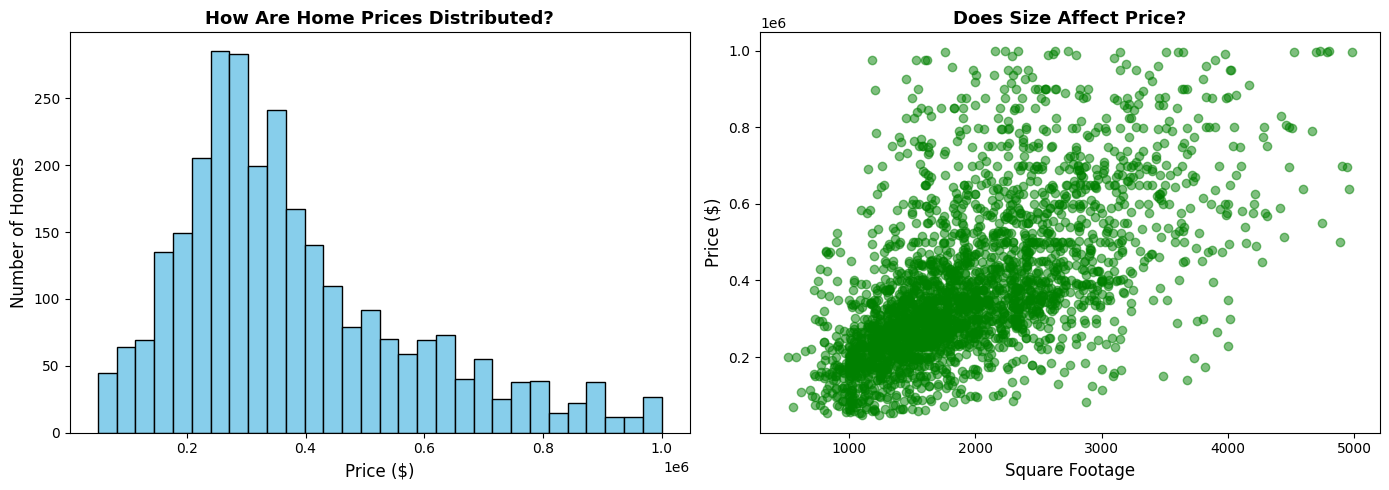

💡 What do we see?
   • Most homes are priced between $200K-$400K
   • Bigger homes cost more - clear relationship!


In [4]:
# Create two simple plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price distribution
axes[0].hist(df_clean['listPrice'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Number of Homes', fontsize=12)
axes[0].set_title('How Are Home Prices Distributed?', fontsize=13, fontweight='bold')

# Plot 2: Price vs Square Footage
axes[1].scatter(df_clean['sqft'], df_clean['listPrice'], alpha=0.5, color='green')
axes[1].set_xlabel('Square Footage', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title('Does Size Affect Price?', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 What do we see?")
print("   • Most homes are priced between $200K-$400K")
print("   • Bigger homes cost more - clear relationship!")

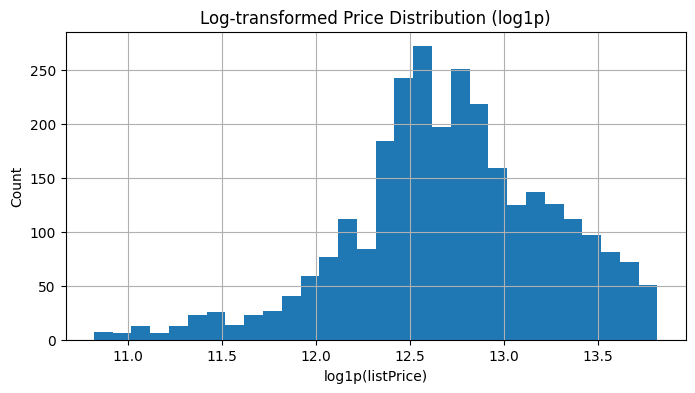

In [5]:
import numpy as np
plt.figure(figsize=(8,4))
np.log1p(df_clean["listPrice"]).hist(bins=30)
plt.title("Log-transformed Price Distribution (log1p)")
plt.xlabel("log1p(listPrice)")
plt.ylabel("Count")
plt.show()


In [6]:
import pandas as pd
num_cols = df_clean.select_dtypes(include="number").columns
corr = df_clean[num_cols].corr()["listPrice"].sort_values(ascending=False)
display(corr)


listPrice     1.000000
sqft          0.607939
baths         0.593881
stories       0.434440
beds          0.370391
year_built    0.296547
age          -0.276463
Name: listPrice, dtype: float64

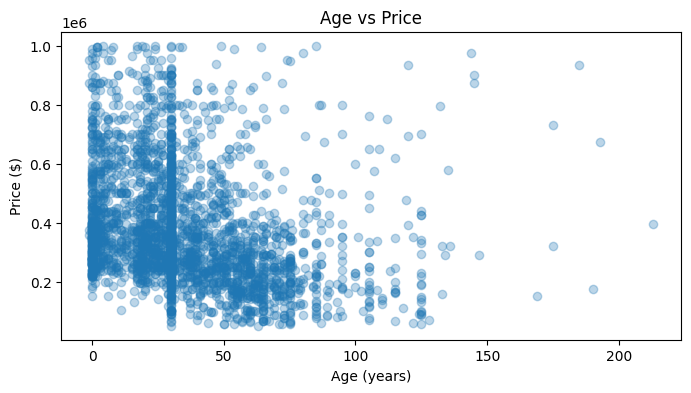

In [7]:
plt.figure(figsize=(8,4))
plt.scatter(df_clean["age"], df_clean["listPrice"], alpha=0.3)
plt.title("Age vs Price")
plt.xlabel("Age (years)")
plt.ylabel("Price ($)")
plt.show()

### 🤖 Step 2: Prepare Data for Machine Learning

In [8]:
# Step 2: Prepare Data for Machine Learning (Improved features)

# 1) Ensure 'stories' has no missing values (Option A: fill with median)
df_clean['stories'] = df_clean['stories'].fillna(df_clean['stories'].median())

# 2) Select features (added 'stories')
features = ['sqft', 'baths', 'beds', 'age', 'stories']
X = df_clean[features]

# 3) Target
y = df_clean['listPrice']

print("📊 Our Improved Model Will Use These Features:")
for f in features:
    print(f" - {f}")
print("\n🎯 Target: listPrice")


📊 Our Improved Model Will Use These Features:
 - sqft
 - baths
 - beds
 - age
 - stories

🎯 Target: listPrice


In [9]:
print("Stories summary:")
display(df_clean['stories'].describe())

print("\nMost common stories values:")
display(df_clean['stories'].value_counts().head(10))


Stories summary:


count    2857.000000
mean        1.354918
std         0.505610
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: stories, dtype: float64


Most common stories values:


stories
1.0    1880
2.0     941
3.0      35
4.0       1
Name: count, dtype: int64

In [10]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📚 Training set: {len(X_train):,} homes")
print(f"🧪 Test set: {len(X_test):,} homes")
print(f"\n💡 Why split?")
print(f"   Training: Model learns from these")
print(f"   Testing: Model proves it can predict NEW homes it never saw")

📚 Training set: 2,285 homes
🧪 Test set: 572 homes

💡 Why split?
   Training: Model learns from these
   Testing: Model proves it can predict NEW homes it never saw


### 🚀 Step 3: Train the Machine Learning Model

In [11]:
# Create the model
print("🤖 Training models...\n")

# Baseline model
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)

# Improved model (more trees)
improved_model = RandomForestRegressor(n_estimators=300, random_state=42)
improved_model.fit(X_train, y_train)

print("✅ Training complete!")
print(f"🌳 Baseline trees: 100 | Improved trees: 300")
print(f"📚 Training rows: {len(X_train):,}")


🤖 Training models...

✅ Training complete!
🌳 Baseline trees: 100 | Improved trees: 300
📚 Training rows: 2,285


### 📊 Step 4: Evaluate the Model

In [12]:
# Make predictions
from sklearn.metrics import mean_absolute_error, r2_score

print("📊 Evaluating models...\n")

# Predictions
baseline_preds = baseline_model.predict(X_test)
improved_preds = improved_model.predict(X_test)

# Metrics
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_r2  = r2_score(y_test, baseline_preds)

improved_mae = mean_absolute_error(y_test, improved_preds)
improved_r2  = r2_score(y_test, improved_preds)

print("=" * 55)
print("✅ MODEL PERFORMANCE (Test Set)")
print("=" * 55)

print(f"🌳 Baseline (100 trees)  | MAE: ${baseline_mae:,.0f} | R²: {baseline_r2:.3f}")
print(f"🚀 Improved (300 trees)  | MAE: ${improved_mae:,.0f} | R²: {improved_r2:.3f}")

# Quick conclusion
print("\n🧠 Quick takeaway:")
if improved_mae < baseline_mae:
    print("✅ Improved model reduced MAE (better average error).")
else:
    print("⚠️ Improved model did NOT reduce MAE (no improvement in average error).")

if improved_r2 > baseline_r2:
    print("✅ Improved model increased R² (explains more price variation).")
else:
    print("⚠️ Improved model did NOT increase R².")


📊 Evaluating models...

✅ MODEL PERFORMANCE (Test Set)
🌳 Baseline (100 trees)  | MAE: $108,569 | R²: 0.404
🚀 Improved (300 trees)  | MAE: $108,135 | R²: 0.409

🧠 Quick takeaway:
✅ Improved model reduced MAE (better average error).
✅ Improved model increased R² (explains more price variation).


#### 📉 Visualize: How Good Are Our Predictions?

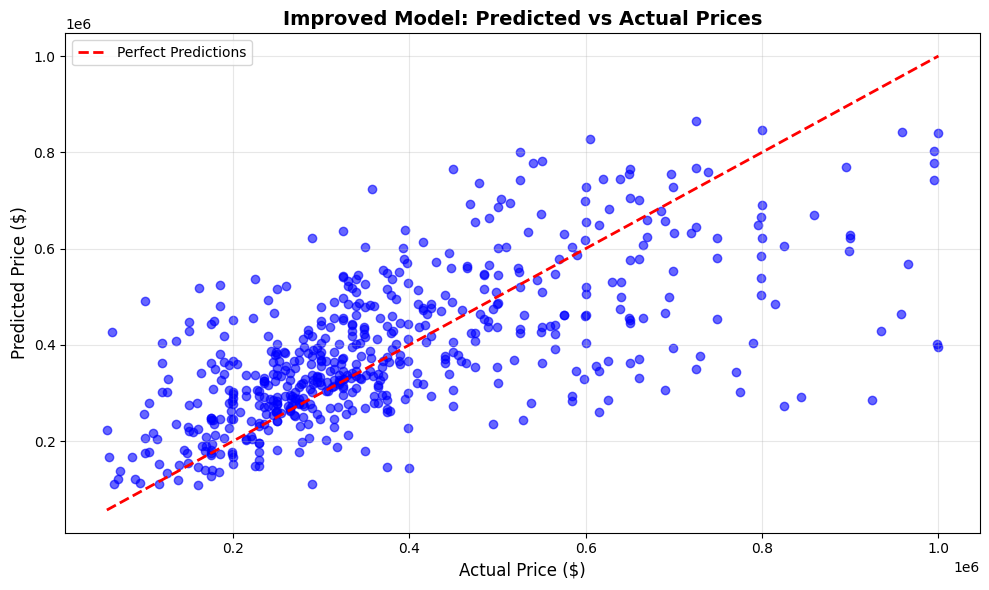

💡 How to read this:
  • Each dot is one home
  • Closer to the red line = more accurate prediction
  • Points above the line = overestimation; below = underestimation


In [13]:
# Create a simple plot
# Visualize: Improved model predictions vs actual
plt.figure(figsize=(10, 6))

plt.scatter(y_test, improved_preds, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Predictions')

plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Improved Model: Predicted vs Actual Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 How to read this:")
print("  • Each dot is one home")
print("  • Closer to the red line = more accurate prediction")
print("  • Points above the line = overestimation; below = underestimation")


#### 🔍 Which Features Matter Most?

In [14]:
# Get feature importance from the improved model
importance = improved_model.feature_importances_

print("🎯 Most Important Features for Predicting Price (Improved Model):\n")
for feature, imp in zip(features, importance):
    print(f"  {feature:12s}: {'█' * int(imp * 50)} {imp:.1%}")

top_feature = features[int(importance.argmax())]
print(f"\n💡 The model learned that '{top_feature}' matters the most!")


🎯 Most Important Features for Predicting Price (Improved Model):

  sqft        : ██████████████████████████ 52.4%
  baths       : ████████ 17.3%
  beds        : ██ 5.3%
  age         : ██████████ 21.8%
  stories     : █ 3.3%

💡 The model learned that 'sqft' matters the most!


### 🏡 Step 5: Predict Price of a New Home

In [15]:
# Let's predict prices for these homes (using the improved model)
new_homes = pd.DataFrame({
    'sqft': [1800, 2500, 1200],
    'baths': [2, 3, 1],
    'beds': [3, 4, 2],
    'age': [10, 5, 30],
    'stories': [1, 2, 1]  # added to match the trained features
})

predictions = improved_model.predict(new_homes)

print("🏡 Predicting prices for NEW homes (Improved Model):\n")
print("=" * 55)

for i in range(len(new_homes)):
    print(f"\n🏠 Home #{i+1}:")
    print(f"   Size: {new_homes.iloc[i]['sqft']:.0f} sqft")
    print(f"   Bedrooms: {new_homes.iloc[i]['beds']:.0f}")
    print(f"   Bathrooms: {new_homes.iloc[i]['baths']:.0f}")
    print(f"   Age: {new_homes.iloc[i]['age']:.0f} years")
    print(f"   Stories: {new_homes.iloc[i]['stories']:.0f}")
    print(f"➡️  Predicted Price: ${predictions[i]:,.0f}")

print("\n" + "=" * 55)
print("💡 These predictions come from patterns learned from real data!")


🏡 Predicting prices for NEW homes (Improved Model):


🏠 Home #1:
   Size: 1800 sqft
   Bedrooms: 3
   Bathrooms: 2
   Age: 10 years
   Stories: 1
➡️  Predicted Price: $397,127

🏠 Home #2:
   Size: 2500 sqft
   Bedrooms: 4
   Bathrooms: 3
   Age: 5 years
   Stories: 2
➡️  Predicted Price: $530,334

🏠 Home #3:
   Size: 1200 sqft
   Bedrooms: 2
   Bathrooms: 1
   Age: 30 years
   Stories: 1
➡️  Predicted Price: $181,888

💡 These predictions come from patterns learned from real data!
